# Smartphone ML Intelligence

## 03 — Smartphone Price Prediction

### Objective

Build leakage-safe machine learning pipelines to estimate smartphone prices from structured technical specifications.

Two experiments are evaluated:

1. **Specification-only model** — uses hardware, display, camera, battery, build, and brand information.
2. **Benchmark-enhanced model** — additionally includes Antutu and Geekbench performance scores.

The comparison helps determine how much smartphone pricing can be explained by specifications alone versus benchmark information.

### 1. Imports & Loading


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

from sklearn.model_selection import (
    RepeatedKFold,
    cross_validate,
    cross_val_predict
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

RANDOM_STATE = 42

In [2]:
DATA_PATH = Path("../data/processed/phones_clean.csv")

phones = pd.read_csv(
    DATA_PATH,
    parse_dates=["launch_date"]
)

print(f"Rows: {phones.shape[0]}")
print(f"Columns: {phones.shape[1]}")

phones.head()

Rows: 270
Columns: 47


,name,brand,sale,processor_type,processor,fab,ram_type,rom_type,display_type,size,...,geekbench_multiple,speaker,wireless_charging,ip_rating,price,has_ultrawide,has_third_camera,has_fourth_camera,launch_year,phone_age_days
0,CMF Phone 1,Nothing,Online,Mediatek,Dimensity 7300,4,LPDDR4X,UFS 2.2,Amoled,6.67,...,2949,Mono,False,52,16000,False,True,False,2024,792
1,CMF Phone 2 Pro,Nothing,Online,Mediatek,Dimensity 7300,4,LPDDR4X,UFS 2.2,Amoled,6.77,...,2936,Mono,False,54,19000,True,True,False,2025,468
2,Galaxy A07,Samsung,Offline,Mediatek,Dimensity 6300,6,LPDDR4X,UFS 2.2,IPS LCD,6.70,...,2012,Mono,False,54,20000,False,True,False,2026,215
3,Galaxy A17,Samsung,Offline,Exynos,1330,5,LPDDR4X,UFS 2.2,Amoled,6.70,...,2137,Mono,False,54,28000,True,True,False,2025,375
4,Galaxy A27,Samsung,Offline,Snapdragon,6 Gen 3,4,LPDDR5X,UFS 3.1,Amoled,6.70,...,3192,Mono,False,64,34000,True,True,False,2026,75


### 2. Defining Target

In [3]:
TARGET = "price"
phones[TARGET].describe()



count       270.000000
mean      43545.555556
std       32773.703625
min        9000.000000
25%       22250.000000
50%       30000.000000
75%       55000.000000
max      170000.000000
Name: price, dtype: float64

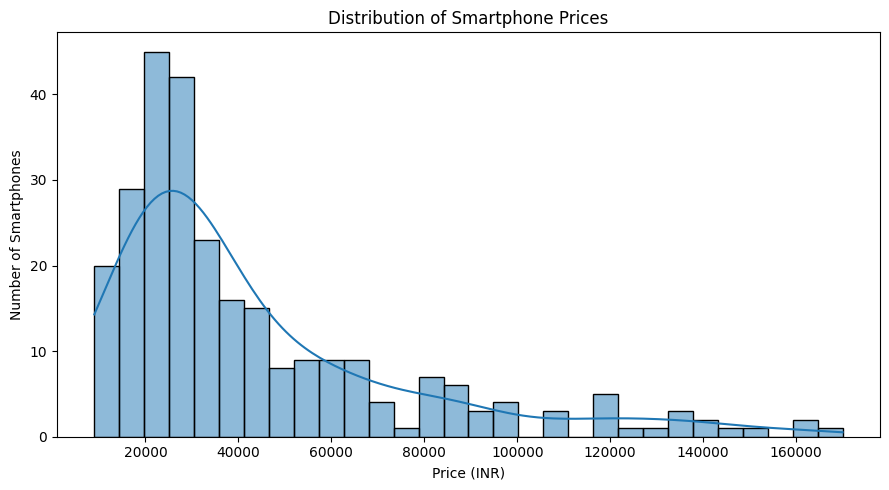

In [4]:
plt.figure(figsize=(9, 5))

sns.histplot(
    phones[TARGET],
    bins=30,
    kde=True
)

plt.title("Distribution of Smartphone Prices")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Smartphones")

plt.tight_layout()
plt.show()

### 3. Filtering & Exploring Features

In [5]:
excluded_features = [
    "price",
    "name",
    "launch_date",
    "colors",
    "camera_sensor_name",
    "processor"
]

In [6]:
benchmark_features = [
    "antutu",
    "geekbench_single",
    "geekbench_multiple"
]

### 4. Experiment A: Prediciting Price without Benchmark Features

In [7]:
spec_features = [
    column
    for column in phones.columns
    if column not in excluded_features + benchmark_features
]

X_spec = phones[spec_features].copy()
y = phones[TARGET].copy()

print("Specification features:", len(spec_features))
print("Target:", TARGET)

X_spec.head()

Specification features: 38
Target: price


,brand,sale,processor_type,fab,ram_type,rom_type,display_type,size,curved_display,refresh_rate,...,front,front_video,speaker,wireless_charging,ip_rating,has_ultrawide,has_third_camera,has_fourth_camera,launch_year,phone_age_days
0,Nothing,Online,Mediatek,4,LPDDR4X,UFS 2.2,Amoled,6.67,False,120,...,16.0,"4, 30",Mono,False,52,False,True,False,2024,792
1,Nothing,Online,Mediatek,4,LPDDR4X,UFS 2.2,Amoled,6.77,False,120,...,16.0,"4, 30",Mono,False,54,True,True,False,2025,468
2,Samsung,Offline,Mediatek,6,LPDDR4X,UFS 2.2,IPS LCD,6.70,False,120,...,8.0,"1, 30",Mono,False,54,False,True,False,2026,215
3,Samsung,Offline,Exynos,5,LPDDR4X,UFS 2.2,Amoled,6.70,False,90,...,13.0,"1, 30",Mono,False,54,True,True,False,2025,375
4,Samsung,Offline,Snapdragon,4,LPDDR5X,UFS 3.1,Amoled,6.70,False,120,...,12.0,"1, 30",Mono,False,64,True,True,False,2026,75


In [8]:
numeric_features = (
    X_spec
    .select_dtypes(include=["number", "bool"])
    .columns
    .tolist()
)

categorical_features = (
    X_spec
    .select_dtypes(include=["object", "string", "category"])
    .columns
    .tolist()
)

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['fab', 'size', 'curved_display', 'refresh_rate', 'hbm', 'ppi', 'battery', 'charging_speed', 'thickness', 'weight', 'camera_number', 'useful_camera_number', 'main', 'ultrawide', 'third_mp', 'fourth_mp', 'front', 'wireless_charging', 'ip_rating', 'has_ultrawide', 'has_third_camera', 'has_fourth_camera', 'launch_year', 'phone_age_days']

Categorical features:
['brand', 'sale', 'processor_type', 'ram_type', 'rom_type', 'display_type', 'protection', 'back_material', 'frame_material', 'third', 'fourth', 'rear_video', 'front_video', 'speaker']


### 5. Building preprocessing pipeline

For numeric variables:

missing value
→ median imputation
→ scaling

For categorical variables:

missing value
→ most frequent category
→ one-hot encoding

In [9]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

### Leakage-safe preprocessing

All imputation, scaling, and categorical encoding are performed inside the Scikit-learn pipeline.

During cross-validation, preprocessing is fitted only on the training portion of each fold. This prevents information from validation observations from influencing the training process.

### 6. Cross-validation strategy

In [11]:
cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=RANDOM_STATE
)

### 7. Initial baseline

In [12]:
dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DummyRegressor(
                strategy="median"
            )
        )
    ]
)

In [13]:
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

In [14]:
dummy_results = cross_validate(
    dummy_pipeline,
    X_spec,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [15]:
dummy_mae = -dummy_results["test_mae"].mean()
dummy_rmse = -dummy_results["test_rmse"].mean()
dummy_r2 = dummy_results["test_r2"].mean()

print(f"Dummy MAE:  {dummy_mae:,.0f}")
print(f"Dummy RMSE: {dummy_rmse:,.0f}")
print(f"Dummy R²:   {dummy_r2:.3f}")

Dummy MAE:  22,011
Dummy RMSE: 34,883
Dummy R²:   -0.161


### 8. Linear Regression

In [16]:
linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LinearRegression()
        )
    ]
)

In [17]:
linear_results = cross_validate(
    linear_pipeline,
    X_spec,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [18]:
linear_mae = -linear_results["test_mae"].mean()
linear_rmse = -linear_results["test_rmse"].mean()
linear_r2 = linear_results["test_r2"].mean()

print(f"Linear MAE:  {linear_mae:,.0f}")
print(f"Linear RMSE: {linear_rmse:,.0f}")
print(f"Linear R²:   {linear_r2:.3f}")

Linear MAE:  7,835
Linear RMSE: 11,533
Linear R²:   0.869


### 9. Ridge Regression

In [19]:
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            Ridge(alpha=10.0)
        )
    ]
)

In [20]:
ridge_results = cross_validate(
    ridge_pipeline,
    X_spec,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [21]:
ridge_mae = -ridge_results["test_mae"].mean()
ridge_rmse = -ridge_results["test_rmse"].mean()
ridge_r2 = ridge_results["test_r2"].mean()

print(f"Ridge MAE:  {ridge_mae:,.0f}")
print(f"Ridge RMSE: {ridge_rmse:,.0f}")
print(f"Ridge R²:   {ridge_r2:.3f}")

Ridge MAE:  7,690
Ridge RMSE: 10,724
Ridge R²:   0.887


### 10. Random Forest Regressor

In [22]:
from sklearn.ensemble import RandomForestRegressor
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=500,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [23]:
rf_results = cross_validate(
    rf_pipeline,
    X_spec,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [24]:
rf_mae = -rf_results["test_mae"].mean()
rf_rmse = -rf_results["test_rmse"].mean()
rf_r2 = rf_results["test_r2"].mean()
rf_r2_std = rf_results["test_r2"].std()

print(f"Random Forest MAE:  {rf_mae:,.0f}")
print(f"Random Forest RMSE: {rf_rmse:,.0f}")
print(f"Random Forest R²:   {rf_r2:.3f}")
print(f"Random Forest R² std: {rf_r2_std:.3f}")

Random Forest MAE:  6,745
Random Forest RMSE: 10,288
Random Forest R²:   0.895
Random Forest R² std: 0.033


### 11. Extra Tress Regressor

In [25]:
from sklearn.ensemble import ExtraTreesRegressor
extra_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=500,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [26]:
extra_results = cross_validate(
    extra_pipeline,
    X_spec,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [27]:
extra_mae = -extra_results["test_mae"].mean()
extra_rmse = -extra_results["test_rmse"].mean()
extra_r2 = extra_results["test_r2"].mean()
extra_r2_std = extra_results["test_r2"].std()

print(f"Extra Trees MAE:      {extra_mae:,.0f}")
print(f"Extra Trees RMSE:     {extra_rmse:,.0f}")
print(f"Extra Trees R²:       {extra_r2:.3f}")
print(f"Extra Trees R² std:   {extra_r2_std:.3f}")

Extra Trees MAE:      6,449
Extra Trees RMSE:     9,847
Extra Trees R²:       0.904
Extra Trees R² std:   0.033


### 12. Gradient Boosting Regressor

In [28]:
from sklearn.ensemble import GradientBoostingRegressor
dense_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

dense_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            dense_categorical_pipeline,
            categorical_features
        )
    ]
)

In [29]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", dense_preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.03,
                max_depth=2,
                min_samples_leaf=3,
                random_state=RANDOM_STATE
            )
        )
    ]
)

In [30]:
gb_results = cross_validate(
    gb_pipeline,
    X_spec,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [31]:
gb_mae = -gb_results["test_mae"].mean()
gb_rmse = -gb_results["test_rmse"].mean()
gb_r2 = gb_results["test_r2"].mean()
gb_r2_std = gb_results["test_r2"].std()

print(f"Gradient Boosting MAE:      {gb_mae:,.0f}")
print(f"Gradient Boosting RMSE:     {gb_rmse:,.0f}")
print(f"Gradient Boosting R²:       {gb_r2:.3f}")
print(f"Gradient Boosting R² std:   {gb_r2_std:.3f}")

Gradient Boosting MAE:      6,582
Gradient Boosting RMSE:     9,810
Gradient Boosting R²:       0.906
Gradient Boosting R² std:   0.022


### 12.1 Log-price modelling - Gradient Boosting

In [32]:
from sklearn.compose import TransformedTargetRegressor

gb_log_model = TransformedTargetRegressor(
    regressor=gb_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

In [33]:
gb_log_results = cross_validate(
    gb_log_model,
    X_spec,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [34]:
gb_log_mae = -gb_log_results["test_mae"].mean()
gb_log_rmse = -gb_log_results["test_rmse"].mean()
gb_log_r2 = gb_log_results["test_r2"].mean()
gb_log_r2_std = gb_log_results["test_r2"].std()

print(f"Log Gradient Boosting MAE:    {gb_log_mae:,.0f}")
print(f"Log Gradient Boosting RMSE:   {gb_log_rmse:,.0f}")
print(f"Log Gradient Boosting R²:     {gb_log_r2:.3f}")
print(f"Log Gradient Boosting R² std: {gb_log_r2_std:.3f}")

Log Gradient Boosting MAE:    6,384
Log Gradient Boosting RMSE:   9,907
Log Gradient Boosting R²:     0.904
Log Gradient Boosting R² std: 0.031


### 13. Experiment B — Adding benchmark information

In [35]:
benchmark_features = [
    "antutu",
    "geekbench_single",
    "geekbench_multiple"
]

full_features = spec_features + benchmark_features

X_full = phones[full_features].copy()

print("Specification-only features:", X_spec.shape[1])
print("Benchmark-enhanced features:", X_full.shape[1])

Specification-only features: 38
Benchmark-enhanced features: 41


In [36]:
numeric_features_full = (
    X_full
    .select_dtypes(include=["number", "bool"])
    .columns
    .tolist()
)

categorical_features_full = (
    X_full
    .select_dtypes(include=["object", "string", "category"])
    .columns
    .tolist()
)

In [37]:
dense_preprocessor_full = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features_full
        ),
        (
            "categorical",
            dense_categorical_pipeline,
            categorical_features_full
        )
    ]
)

In [38]:
gb_benchmark_pipeline = Pipeline(
    steps=[
        ("preprocessor", dense_preprocessor_full),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.03,
                max_depth=2,
                min_samples_leaf=3,
                random_state=RANDOM_STATE
            )
        )
    ]
)

In [39]:
gb_benchmark_results = cross_validate(
    gb_benchmark_pipeline,
    X_full,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [40]:
gb_benchmark_mae = -gb_benchmark_results["test_mae"].mean()
gb_benchmark_rmse = -gb_benchmark_results["test_rmse"].mean()
gb_benchmark_r2 = gb_benchmark_results["test_r2"].mean()
gb_benchmark_r2_std = gb_benchmark_results["test_r2"].std()

print(f"Benchmark GB MAE:    {gb_benchmark_mae:,.0f}")
print(f"Benchmark GB RMSE:   {gb_benchmark_rmse:,.0f}")
print(f"Benchmark GB R²:     {gb_benchmark_r2:.3f}")
print(f"Benchmark GB R² std: {gb_benchmark_r2_std:.3f}")

Benchmark GB MAE:    6,790
Benchmark GB RMSE:   10,300
Benchmark GB R²:     0.896
Benchmark GB R² std: 0.028


In [41]:
print(
    f"MAE change: "
    f"{gb_mae - gb_benchmark_mae:,.0f} INR"
)

print(
    f"RMSE change: "
    f"{gb_rmse - gb_benchmark_rmse:,.0f} INR"
)

print(
    f"R² change: "
    f"{gb_benchmark_r2 - gb_r2:+.3f}"
)

MAE change: -208 INR
RMSE change: -490 INR
R² change: -0.011


### Benchmark Feature Ablation

Adding Antutu and Geekbench scores did not improve price prediction. The benchmark-enhanced model produced slightly worse cross-validated error and R² than the specification-only model.

This suggests that benchmark performance provides limited additional pricing information once the underlying smartphone specifications are already available. Benchmark scores are likely partly redundant with hardware characteristics such as chipset, memory, storage, and fabrication technology.

Therefore, the specification-only feature set is retained for the final price model.